# BUISSNESS PROBLEM
'''The business problem is to reduce stockouts and overstock by forecasting future revenue and product demand and helping the company make better inventory and reorder decisions using data.'''


## importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading Data

In [3]:
# this library is used to know that where is your jupyrt file is located

In [4]:
df=pd.read_csv(r"C:\Users\Admin\FORESIGHT_5_Year_90000_Rows.csv")

In [5]:
df

,date,sku_id,category,subcategory,product_name,units_sold,revenue,unit_price,unit_cost,list_price,...,on_order_units,lead_time_days,reorder_point,Year,Month,weekend,Profit,Risk_Status,Profit_Margin,Reorder_Needed
0,2020-08-01,SKU005,3,Cookware,Cookware 1,12,6736.43,561.37,455.74,759.04,...,1,5,70,2020,8,1,1267.55,Stockout Risk,18.816346,1
1,2020-08-01,SKU013,3,Vase,Vase 2,7,8283.70,1183.39,309.39,576.27,...,1,14,60,2020,8,1,6117.97,Stockout Risk,73.855523,1
2,2020-08-01,SKU011,3,Fan,Fan 3,11,7763.83,705.80,200.36,301.74,...,5,11,54,2020,8,1,5559.87,Stockout Risk,71.612464,1
3,2020-05-01,SKU012,3,Lamp,Lamp 4,21,8108.10,386.10,156.99,299.95,...,26,12,77,2020,5,0,4811.31,Stockout Risk,59.339549,1
4,2020-08-01,SKU018,2,Iron,Iron 5,5,5692.54,1138.51,223.77,372.73,...,12,5,59,2020,8,1,4573.69,Normal,80.345329,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,2024-11-01,SKU005,3,Unknown,unknown,11,6007.89,546.17,455.74,759.04,...,16,5,53,2024,11,0,994.75,Stockout Risk,16.557394,1
89996,2024-10-01,SKU015,2,Unknown,unknown,10,7175.63,717.56,401.32,726.35,...,2,4,103,2024,10,0,3162.43,Stockout Risk,44.071810,1
89997,2024-03-01,SKU012,3,Unknown,unknown,12,9363.08,780.26,156.99,299.95,...,24,14,90,2024,3,0,7479.20,Stockout Risk,79.879698,1
89998,2024-06-01,SKU010,0,Unknown,unknown,17,6853.59,403.15,292.37,594.58,...,28,11,87,2024,6,1,1883.30,Stockout Risk,27.479029,1


In [6]:
df.shape

(90000, 26)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90000 non-null  object 
 1   sku_id          90000 non-null  object 
 2   category        90000 non-null  int64  
 3   subcategory     90000 non-null  object 
 4   product_name    90000 non-null  object 
 5   units_sold      90000 non-null  int64  
 6   revenue         90000 non-null  float64
 7   unit_price      90000 non-null  float64
 8   unit_cost       90000 non-null  float64
 9   list_price      90000 non-null  float64
 10  promo_flag      90000 non-null  int64  
 11  week            90000 non-null  int64  
 12  season          90000 non-null  int64  
 13  is_holiday      90000 non-null  int64  
 14  promo_event     90000 non-null  object 
 15  on_hand_units   90000 non-null  int64  
 16  on_order_units  90000 non-null  int64  
 17  lead_time_days  90000 non-null 

In [8]:
# to know where is your datasets

In [9]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Admin
['.anaconda', '.conda', '.continuum', '.copilot', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '.vscode-shared', '3D Objects', 'aaaa.txt', 'anaconda3', 'app.py', 'AppData', 'Application Data', 'BlinkIT Grocery Data.xlsx', 'calendar.csv', 'Contacts', 'Cookies', 'datasets', 'Dealing_and_Handling_different_types_of_data.ipynb', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'feature_names.pkl', 'FORESIGHT AND INVENTORY PROJECT', 'FORESIGHT.ipynb', 'FORESIGHT_5_Year_90000_Rows.csv', 'foresight_dataset.csv', 'foresight_final_dashboard.csv', 'foresight_flask', 'Foresight_project.csv', 'inventory_snapshots.csv', 'Links', 'Local Settings', 'Microsoft', 'model_features.pkl', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-0

# checking datasets

# finding missing values

In [10]:
df.isnull().sum()

date              0
sku_id            0
category          0
subcategory       0
product_name      0
units_sold        0
revenue           0
unit_price        0
unit_cost         0
list_price        0
promo_flag        0
week              0
season            0
is_holiday        0
promo_event       0
on_hand_units     0
on_order_units    0
lead_time_days    0
reorder_point     0
Year              0
Month             0
weekend           0
Profit            0
Risk_Status       0
Profit_Margin     0
Reorder_Needed    0
dtype: int64

# filling missing values

In [11]:
df["promo_event"] =  df["promo_event"].fillna("no promo")

In [12]:
df["subcategory"]= df["subcategory"].fillna("Unknown")

In [13]:
df["product_name"]= df["product_name"].fillna("unknown")

In [14]:
df.isnull().sum()

date              0
sku_id            0
category          0
subcategory       0
product_name      0
units_sold        0
revenue           0
unit_price        0
unit_cost         0
list_price        0
promo_flag        0
week              0
season            0
is_holiday        0
promo_event       0
on_hand_units     0
on_order_units    0
lead_time_days    0
reorder_point     0
Year              0
Month             0
weekend           0
Profit            0
Risk_Status       0
Profit_Margin     0
Reorder_Needed    0
dtype: int64

# checking duplicate

In [15]:
df.duplicated().sum()

np.int64(18242)

In [16]:
df.shape

(90000, 26)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90000 non-null  object 
 1   sku_id          90000 non-null  object 
 2   category        90000 non-null  int64  
 3   subcategory     90000 non-null  object 
 4   product_name    90000 non-null  object 
 5   units_sold      90000 non-null  int64  
 6   revenue         90000 non-null  float64
 7   unit_price      90000 non-null  float64
 8   unit_cost       90000 non-null  float64
 9   list_price      90000 non-null  float64
 10  promo_flag      90000 non-null  int64  
 11  week            90000 non-null  int64  
 12  season          90000 non-null  int64  
 13  is_holiday      90000 non-null  int64  
 14  promo_event     90000 non-null  object 
 15  on_hand_units   90000 non-null  int64  
 16  on_order_units  90000 non-null  int64  
 17  lead_time_days  90000 non-null 

In [18]:
df.head()

,date,sku_id,category,subcategory,product_name,units_sold,revenue,unit_price,unit_cost,list_price,...,on_order_units,lead_time_days,reorder_point,Year,Month,weekend,Profit,Risk_Status,Profit_Margin,Reorder_Needed
0,2020-08-01,SKU005,3,Cookware,Cookware 1,12,6736.43,561.37,455.74,759.04,...,1,5,70,2020,8,1,1267.55,Stockout Risk,18.816346,1
1,2020-08-01,SKU013,3,Vase,Vase 2,7,8283.70,1183.39,309.39,576.27,...,1,14,60,2020,8,1,6117.97,Stockout Risk,73.855523,1
2,2020-08-01,SKU011,3,Fan,Fan 3,11,7763.83,705.80,200.36,301.74,...,5,11,54,2020,8,1,5559.87,Stockout Risk,71.612464,1
3,2020-05-01,SKU012,3,Lamp,Lamp 4,21,8108.10,386.10,156.99,299.95,...,26,12,77,2020,5,0,4811.31,Stockout Risk,59.339549,1
4,2020-08-01,SKU018,2,Iron,Iron 5,5,5692.54,1138.51,223.77,372.73,...,12,5,59,2020,8,1,4573.69,Normal,80.345329,0


# EDA 

In [19]:
df.nunique()

date                60
sku_id              20
category             4
subcategory         33
product_name       201
units_sold          26
revenue           1197
unit_price        1186
unit_cost           20
list_price          20
promo_flag           2
week                22
season               4
is_holiday           2
promo_event          2
on_hand_units       88
on_order_units      42
lead_time_days      12
reorder_point      128
Year                 5
Month               12
weekend              2
Profit            1198
Risk_Status          2
Profit_Margin     1200
Reorder_Needed       2
dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90000 non-null  object 
 1   sku_id          90000 non-null  object 
 2   category        90000 non-null  int64  
 3   subcategory     90000 non-null  object 
 4   product_name    90000 non-null  object 
 5   units_sold      90000 non-null  int64  
 6   revenue         90000 non-null  float64
 7   unit_price      90000 non-null  float64
 8   unit_cost       90000 non-null  float64
 9   list_price      90000 non-null  float64
 10  promo_flag      90000 non-null  int64  
 11  week            90000 non-null  int64  
 12  season          90000 non-null  int64  
 13  is_holiday      90000 non-null  int64  
 14  promo_event     90000 non-null  object 
 15  on_hand_units   90000 non-null  int64  
 16  on_order_units  90000 non-null  int64  
 17  lead_time_days  90000 non-null 

In [21]:
df.columns

Index(['date', 'sku_id', 'category', 'subcategory', 'product_name',
       'units_sold', 'revenue', 'unit_price', 'unit_cost', 'list_price',
       'promo_flag', 'week', 'season', 'is_holiday', 'promo_event',
       'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point',
       'Year', 'Month', 'weekend', 'Profit', 'Risk_Status', 'Profit_Margin',
       'Reorder_Needed'],
      dtype='object')

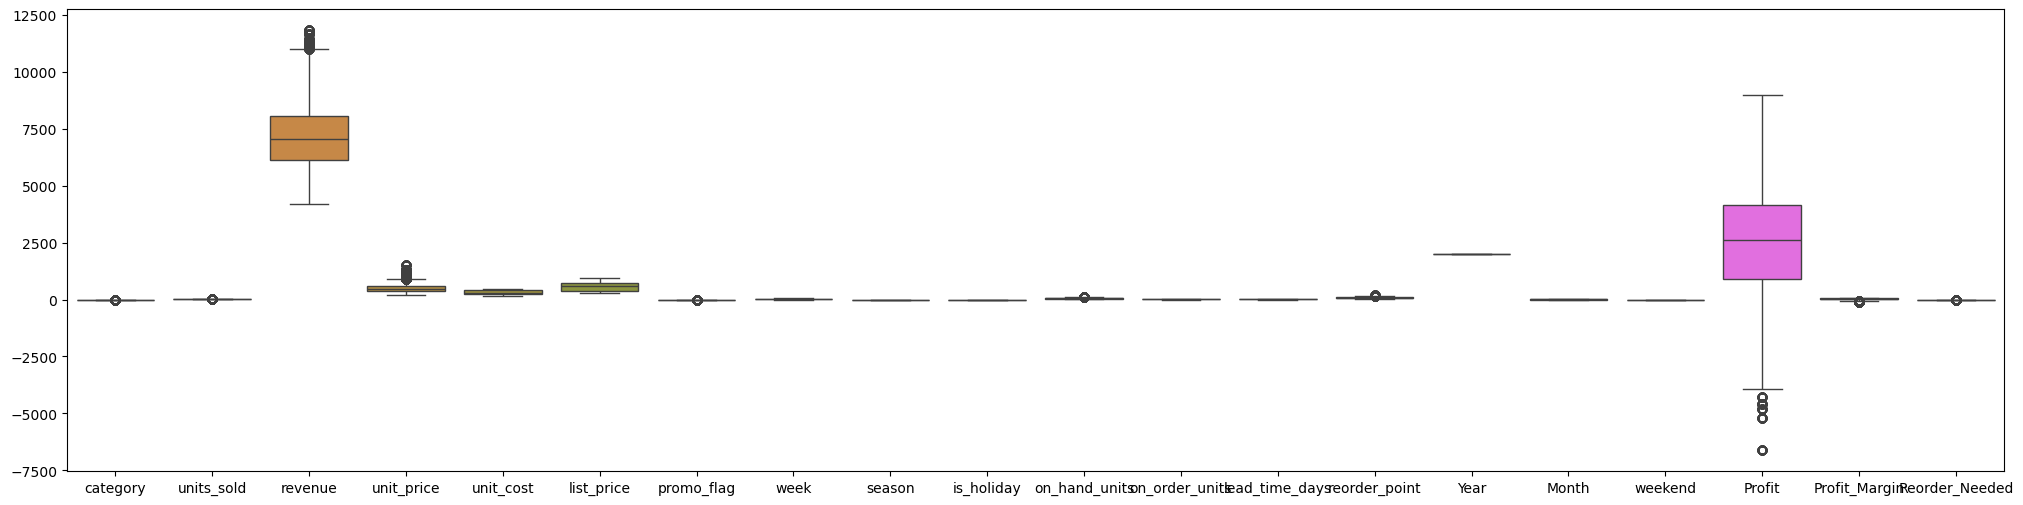

In [22]:
# Detecting and handling the Outlier
import seaborn as sns
#import matplotlib.pyplot as plt
plt.figure(figsize=(25,6))
sns.boxplot(df)
plt.show()



In [23]:
import numpy as np

# IQR method on revenue
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outlier = df[(df['revenue'] >= lower) & (df['revenue'] <= upper)]

print('Original rows:', len(df))
print('After removing revenue outliers:', len(df_no_outlier))

Original rows: 90000
After removing revenue outliers: 89351


In [24]:
import numpy as np

# IQR method on profit
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outlier = df[(df['Profit'] >= lower) & (df['Profit'] <= upper)]

print('Original rows:', len(df))
print('After removing Profit outliers:', len(df_no_outlier))

Original rows: 90000
After removing Profit outliers: 89640


In [25]:
df.describe()

,category,units_sold,revenue,unit_price,unit_cost,list_price,promo_flag,week,season,is_holiday,on_hand_units,on_order_units,lead_time_days,reorder_point,Year,Month,weekend,Profit,Profit_Margin,Reorder_Needed
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,2.150600,15.319422,7181.280238,506.969335,307.187188,564.224575,0.110867,26.936456,1.500211,0.417600,49.678178,14.834911,8.717956,84.396800,2022.000000,6.486411,0.266511,2470.928233,32.844745,0.883822
std,0.909405,4.444088,1366.974453,173.841548,101.505146,200.917719,0.313969,15.111647,1.117732,0.493166,18.765112,9.210313,3.508445,27.878219,1.414221,3.453615,0.442137,2366.806884,31.282992,0.320440
min,0.000000,5.000000,4201.050000,211.160000,152.610000,274.070000,0.000000,1.000000,0.000000,0.000000,15.000000,0.000000,3.000000,32.000000,2020.000000,1.000000,0.000000,-6613.750000,-112.182789,0.000000
25%,2.000000,12.000000,6129.760000,380.920000,223.770000,372.730000,0.000000,14.000000,1.000000,0.000000,34.000000,7.000000,6.000000,63.000000,2021.000000,3.000000,0.000000,887.960000,13.375304,1.000000
50%,2.000000,15.000000,7075.540000,471.620000,296.080000,576.270000,0.000000,27.000000,1.000000,0.000000,48.000000,14.000000,9.000000,82.000000,2022.000000,6.000000,0.000000,2614.870000,38.387400,1.000000
75%,3.000000,18.000000,8081.420000,588.990000,406.280000,726.350000,0.000000,40.000000,3.000000,1.000000,63.000000,21.000000,12.000000,103.000000,2023.000000,9.000000,1.000000,4148.290000,57.692702,1.000000
max,3.000000,31.000000,11837.100000,1515.600000,460.310000,943.000000,1.000000,53.000000,3.000000,1.000000,112.000000,41.000000,14.000000,181.000000,2024.000000,12.000000,1.000000,8992.620000,87.155824,1.000000


# top 10 selling product

In [26]:
top_products=df.groupby("sku_id")["units_sold"].sum().sort_values(ascending= False)
top_products

sku_id
SKU010    71464
SKU020    71450
SKU002    71289
SKU011    70953
SKU008    70923
SKU018    70572
SKU013    70155
SKU016    70056
SKU009    69246
SKU017    68925
SKU005    68700
SKU001    68461
SKU004    68356
SKU006    68001
SKU007    67598
SKU003    67548
SKU019    67338
SKU015    67137
SKU012    66955
SKU014    63621
Name: units_sold, dtype: int64

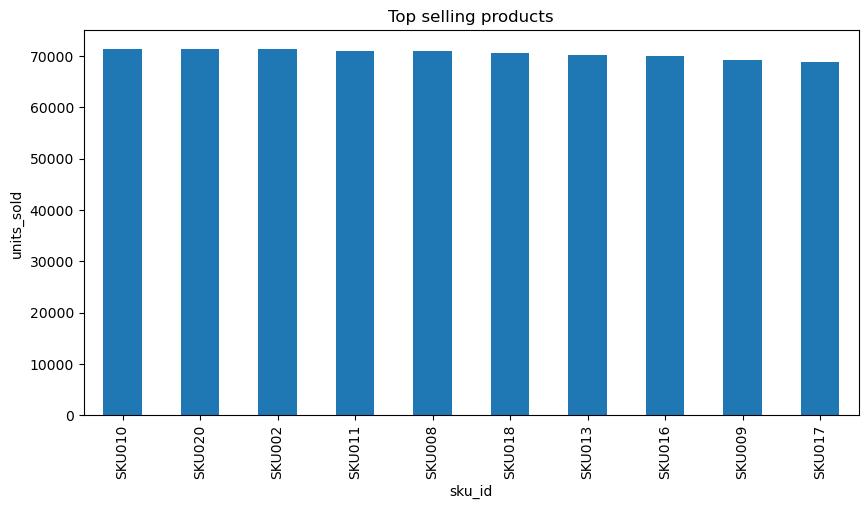

In [27]:
top_products.head(10).plot (kind="bar" , figsize=(10,5))
plt.xlabel("sku_id")
plt.ylabel("units_sold")
plt.title("Top selling products")
plt.show()


In [28]:
#The bar graph shows the top 10 best-selling products based on total units sold. 
#these products have the highest customer demand and contribute significantly to overall sales.
#The company should maintain sufficient inventory for these SKUs to avoid stockouts.

# category wise sale

In [29]:
category_sales=df.groupby("category")["units_sold"].sum()
category_sales


category
0     71464
1    276125
2    413262
3    617897
Name: units_sold, dtype: int64

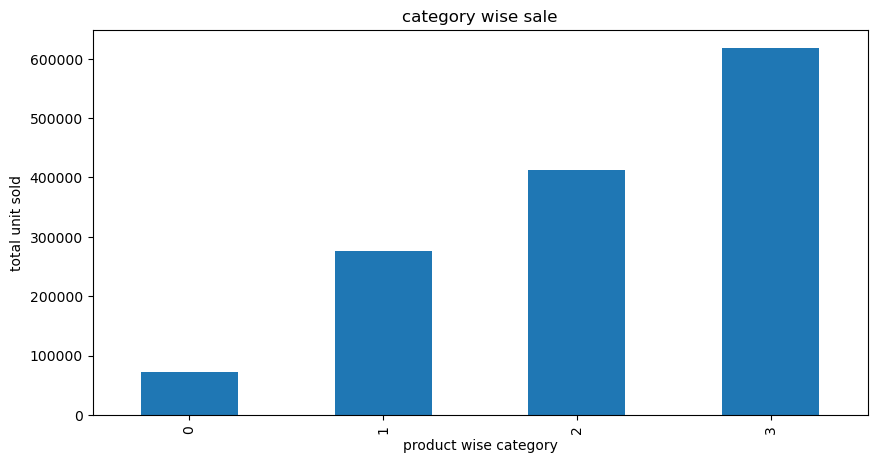

In [30]:
category_sales.plot(kind="bar" ,figsize=(10,5))
plt.title("category wise sale")
plt.xlabel("product wise category")
plt.ylabel("total unit sold")
plt.show()

In [31]:
#This graph compares total sales across different product categories. 
#It helps identify the highest-performing categories and supports better inventory planning and business decision-making.

In [32]:
# daily sales trend

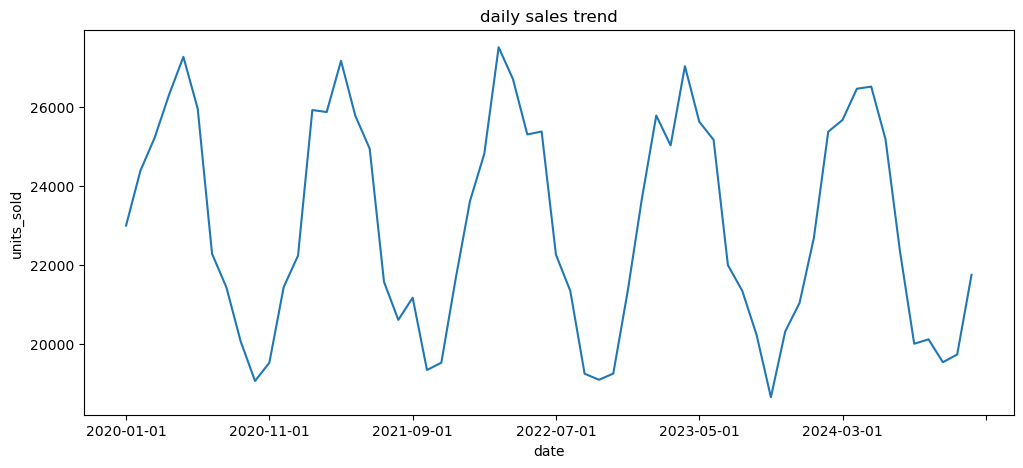

In [33]:
daily_sales=df.groupby('date')["units_sold"].sum()
daily_sales.plot(figsize=(12,5))
plt.xlabel("date")
plt.ylabel("units_sold")
plt.title("daily sales trend")
plt.show()


In [34]:
#The line graph illustrates the daily sales trend over time. 
#It helps identify fluctuations in demand, seasonal patterns, and peak sales periods.

# Monthly sales

In [35]:
df["date"] = pd.to_datetime(df["date"])

df["Month"] = df["date"].dt.month_name()

monthly_sales = df.groupby("Month")["units_sold"].sum()

monthly_sales

Month
April        133639
August       104743
December     107199
February     126252
January      115212
July         110468
June         126600
March        129277
May          130460
November      98361
October       95700
September    100837
Name: units_sold, dtype: int64

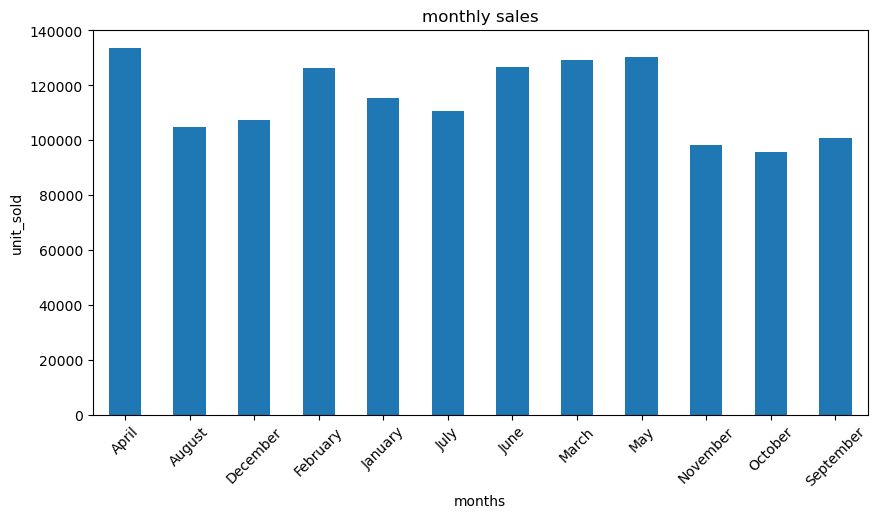

In [36]:
monthly_sales.plot(kind="bar", figsize=(10,5))
plt.title("monthly sales")
plt.xlabel("months")
plt.ylabel("unit_sold")
plt.xticks(rotation=45)
plt.show()

In [37]:
#This graph shows the monthly sales performance. 
#It highlights months with higher or lower sales, which can be useful for demand forecasting and inventory planning.

# revenue trend

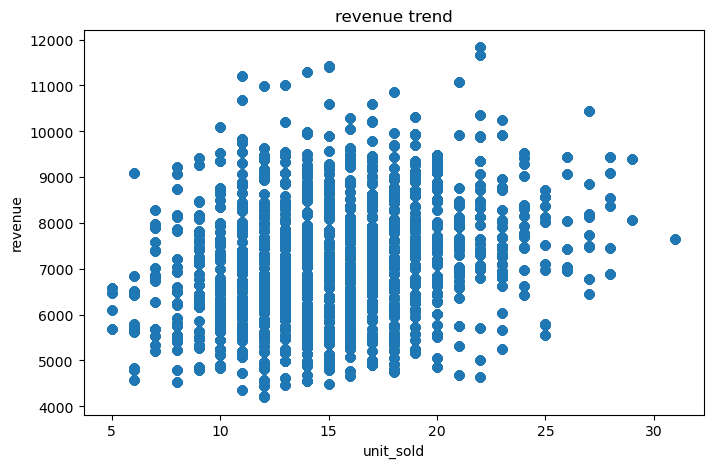

In [38]:
#histogram

plt.figure(figsize=(8,5))
plt.scatter(df["units_sold"],df["revenue"])
plt.ylabel("revenue")
plt.xlabel("unit_sold")
plt.title("revenue trend")
plt.show()


In [39]:
#The revenue trend graph displays changes in total revenue over time.
#It helps evaluate business growth and identify periods of high or low financial performance.

# promotion analysis

In [40]:
promo=df.groupby("promo_flag")["units_sold"].sum()
promo

promo_flag
0    1209929
1     168819
Name: units_sold, dtype: int64

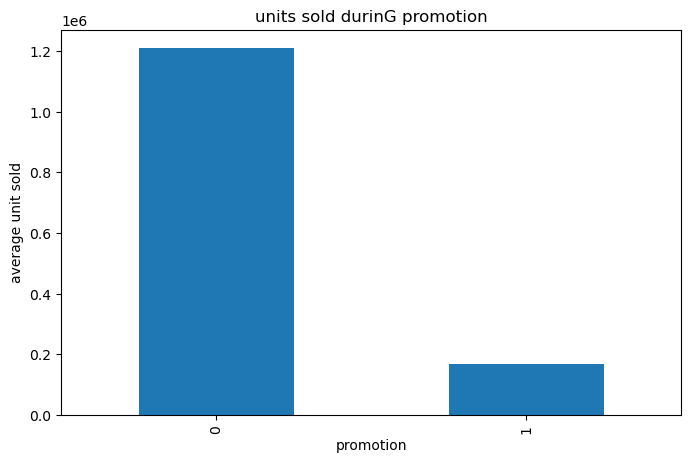

In [41]:
promo.plot(figsize=(8,5), kind="bar")
plt.title("units sold durinG promotion")
plt.xlabel("promotion")
plt.ylabel("average unit sold")
plt.show()

In [42]:
#This graph compares the average units sold during promotional and non-promotional periods. 
 #It helps measure the effectiveness of promotional campaigns on product sales.

# holiday Analysis

In [43]:
holiday=df.groupby('is_holiday')["units_sold"].mean()
holiday

is_holiday
0    16.360138
1    13.868002
Name: units_sold, dtype: float64

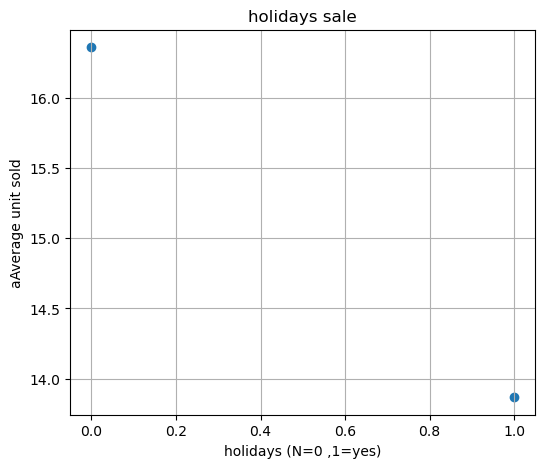

In [44]:
plt.figure(figsize=(6,5))
plt.scatter(holiday.index,holiday.values)
plt.title("holidays sale")
plt.xlabel("holidays (N=0 ,1=yes)")
plt.ylabel("aAverage unit sold")
plt.grid(True)
plt.show()

In [45]:
#The holiday sales graph compares average sales during holidays and non-holiday periods. 
#It helps understand the impact of holidays on customer purchasing behavior.

In [46]:
#inventory Analysis

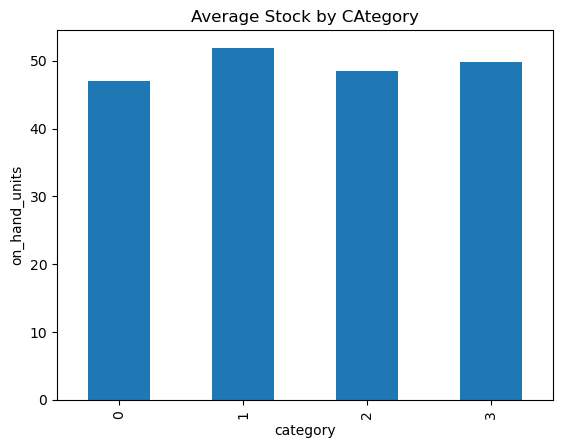

In [47]:
inventory=df.groupby("category")["on_hand_units"].mean()
inventory.plot(kind="bar")
plt.title("Average Stock by CAtegory")
plt.xlabel("category")
plt.ylabel("on_hand_units")
plt.show()

In [48]:
#The Bar plot shows the relationship between available inventory and units sold.
#It helps identify products with low stock, excess stock, and inventory management opportunities.

# correlation


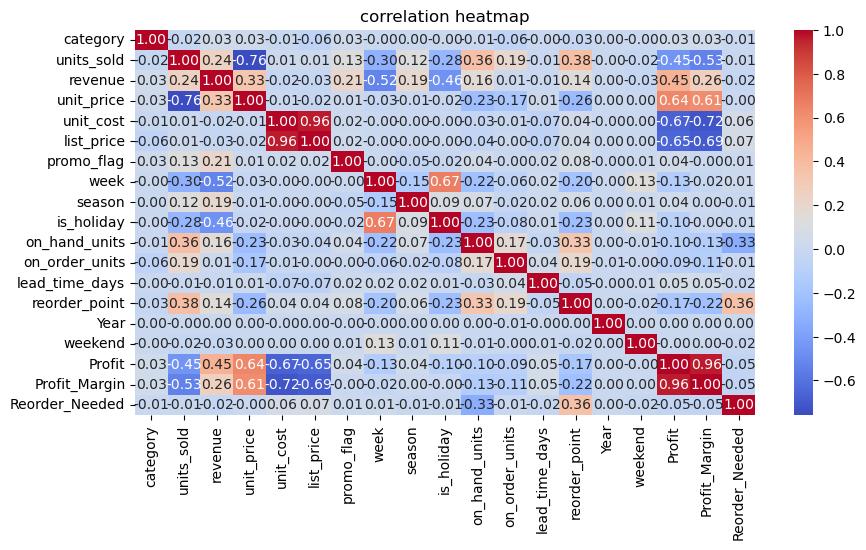

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
numeric= df.select_dtypes(include=["number"])
corr=numeric.corr()
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("correlation heatmap")
plt.show()



In [50]:
#The correlation heatmap shows the relationship between numerical variables in the dataset. 
#It helps identify features that are strongly or weakly correlated, supporting feature selection and better model building.

'''Total EDA summary
The Exploratory Data Analysis (EDA) revealed important insights into sales performance, customer demand, inventory levels, promotions, and seasonal trends. 
The analysis identified high-performing products and categories, evaluated the impact of promotions and holidays, and examined relationships among key business variables.
These insights provide a strong foundation for demand forecasting, inventory optimization, and data-driven decision-making.'''

# Feature Engineering

In [51]:
df.head()


,date,sku_id,category,subcategory,product_name,units_sold,revenue,unit_price,unit_cost,list_price,...,on_order_units,lead_time_days,reorder_point,Year,Month,weekend,Profit,Risk_Status,Profit_Margin,Reorder_Needed
0,2020-08-01,SKU005,3,Cookware,Cookware 1,12,6736.43,561.37,455.74,759.04,...,1,5,70,2020,August,1,1267.55,Stockout Risk,18.816346,1
1,2020-08-01,SKU013,3,Vase,Vase 2,7,8283.70,1183.39,309.39,576.27,...,1,14,60,2020,August,1,6117.97,Stockout Risk,73.855523,1
2,2020-08-01,SKU011,3,Fan,Fan 3,11,7763.83,705.80,200.36,301.74,...,5,11,54,2020,August,1,5559.87,Stockout Risk,71.612464,1
3,2020-05-01,SKU012,3,Lamp,Lamp 4,21,8108.10,386.10,156.99,299.95,...,26,12,77,2020,May,0,4811.31,Stockout Risk,59.339549,1
4,2020-08-01,SKU018,2,Iron,Iron 5,5,5692.54,1138.51,223.77,372.73,...,12,5,59,2020,August,1,4573.69,Normal,80.345329,0


In [52]:
df.columns

Index(['date', 'sku_id', 'category', 'subcategory', 'product_name',
       'units_sold', 'revenue', 'unit_price', 'unit_cost', 'list_price',
       'promo_flag', 'week', 'season', 'is_holiday', 'promo_event',
       'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point',
       'Year', 'Month', 'weekend', 'Profit', 'Risk_Status', 'Profit_Margin',
       'Reorder_Needed'],
      dtype='object')

In [53]:
df.describe()

,date,category,units_sold,revenue,unit_price,unit_cost,list_price,promo_flag,week,season,is_holiday,on_hand_units,on_order_units,lead_time_days,reorder_point,Year,weekend,Profit,Profit_Margin,Reorder_Needed
count,90000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,2022-06-16 05:16:48,2.150600,15.319422,7181.280238,506.969335,307.187188,564.224575,0.110867,26.936456,1.500211,0.417600,49.678178,14.834911,8.717956,84.396800,2022.000000,0.266511,2470.928233,32.844745,0.883822
min,2020-01-01 00:00:00,0.000000,5.000000,4201.050000,211.160000,152.610000,274.070000,0.000000,1.000000,0.000000,0.000000,15.000000,0.000000,3.000000,32.000000,2020.000000,0.000000,-6613.750000,-112.182789,0.000000
25%,2021-04-01 00:00:00,2.000000,12.000000,6129.760000,380.920000,223.770000,372.730000,0.000000,14.000000,1.000000,0.000000,34.000000,7.000000,6.000000,63.000000,2021.000000,0.000000,887.960000,13.375304,1.000000
50%,2022-06-01 00:00:00,2.000000,15.000000,7075.540000,471.620000,296.080000,576.270000,0.000000,27.000000,1.000000,0.000000,48.000000,14.000000,9.000000,82.000000,2022.000000,0.000000,2614.870000,38.387400,1.000000
75%,2023-09-01 00:00:00,3.000000,18.000000,8081.420000,588.990000,406.280000,726.350000,0.000000,40.000000,3.000000,1.000000,63.000000,21.000000,12.000000,103.000000,2023.000000,1.000000,4148.290000,57.692702,1.000000
max,2024-12-01 00:00:00,3.000000,31.000000,11837.100000,1515.600000,460.310000,943.000000,1.000000,53.000000,3.000000,1.000000,112.000000,41.000000,14.000000,181.000000,2024.000000,1.000000,8992.620000,87.155824,1.000000
std,NaN,0.909405,4.444088,1366.974453,173.841548,101.505146,200.917719,0.313969,15.111647,1.117732,0.493166,18.765112,9.210313,3.508445,27.878219,1.414221,0.442137,2366.806884,31.282992,0.320440


# FEATURE ENGINEERING

In [54]:
#Weekend Features
df["weekend"]=(df["date"].dt.weekday >= 5 ).astype(int)
df[["date"  ,"weekend"]].drop_duplicates().head()
                 

,date,weekend
0,2020-08-01,1
3,2020-05-01,0
6,2020-12-01,0
7,2020-11-01,1
9,2020-07-01,0


In [55]:
df.columns

Index(['date', 'sku_id', 'category', 'subcategory', 'product_name',
       'units_sold', 'revenue', 'unit_price', 'unit_cost', 'list_price',
       'promo_flag', 'week', 'season', 'is_holiday', 'promo_event',
       'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point',
       'Year', 'Month', 'weekend', 'Profit', 'Risk_Status', 'Profit_Margin',
       'Reorder_Needed'],
      dtype='object')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90000 non-null  datetime64[ns]
 1   sku_id          90000 non-null  object        
 2   category        90000 non-null  int64         
 3   subcategory     90000 non-null  object        
 4   product_name    90000 non-null  object        
 5   units_sold      90000 non-null  int64         
 6   revenue         90000 non-null  float64       
 7   unit_price      90000 non-null  float64       
 8   unit_cost       90000 non-null  float64       
 9   list_price      90000 non-null  float64       
 10  promo_flag      90000 non-null  int64         
 11  week            90000 non-null  int64         
 12  season          90000 non-null  int64         
 13  is_holiday      90000 non-null  int64         
 14  promo_event     90000 non-null  object        
 15  on

In [57]:
df.drop('Profit_Margin', axis=1, inplace=True)

In [58]:
df.drop('Reorder_Needed', axis=1, inplace=True)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90000 non-null  datetime64[ns]
 1   sku_id          90000 non-null  object        
 2   category        90000 non-null  int64         
 3   subcategory     90000 non-null  object        
 4   product_name    90000 non-null  object        
 5   units_sold      90000 non-null  int64         
 6   revenue         90000 non-null  float64       
 7   unit_price      90000 non-null  float64       
 8   unit_cost       90000 non-null  float64       
 9   list_price      90000 non-null  float64       
 10  promo_flag      90000 non-null  int64         
 11  week            90000 non-null  int64         
 12  season          90000 non-null  int64         
 13  is_holiday      90000 non-null  int64         
 14  promo_event     90000 non-null  object        
 15  on

In [60]:
#profit
df["Profit"]=df["revenue"]-(df["unit_cost"] * df["units_sold"])
df[["revenue","units_sold","unit_cost","Profit"]].head()

,revenue,units_sold,unit_cost,Profit
0,6736.43,12,455.74,1267.55
1,8283.70,7,309.39,6117.97
2,7763.83,11,200.36,5559.87
3,8108.10,21,156.99,4811.31
4,5692.54,5,223.77,4573.69


In [61]:
#Profit Margin 
df["Profit_Margin"]=(df["Profit"]/df["revenue"])* 100
df[["Profit_Margin","Profit" ,"revenue"]]

,Profit_Margin,Profit,revenue
0,18.816346,1267.55,6736.43
1,73.855523,6117.97,8283.70
2,71.612464,5559.87,7763.83
3,59.339549,4811.31,8108.10
4,80.345329,4573.69,5692.54
...,...,...,...
89995,16.557394,994.75,6007.89
89996,44.071810,3162.43,7175.63
89997,79.879698,7479.20,9363.08
89998,27.479029,1883.30,6853.59


In [62]:
#Reorder Needed
df["Reorder_Needed"] = (df["on_hand_units"] < df["reorder_point"]).astype(int)
df[["Reorder_Needed", "on_hand_units", "reorder_point"]].head()

,Reorder_Needed,on_hand_units,reorder_point
0,1,41,70
1,1,37,60
2,1,17,54
3,1,45,77
4,0,61,59


In [63]:
#1 -->  stock is not available, reorder it 
#0 --> stock is available

In [64]:
df.columns

Index(['date', 'sku_id', 'category', 'subcategory', 'product_name',
       'units_sold', 'revenue', 'unit_price', 'unit_cost', 'list_price',
       'promo_flag', 'week', 'season', 'is_holiday', 'promo_event',
       'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point',
       'Year', 'Month', 'weekend', 'Profit', 'Risk_Status', 'Profit_Margin',
       'Reorder_Needed'],
      dtype='object')

In [65]:
df.head()

,date,sku_id,category,subcategory,product_name,units_sold,revenue,unit_price,unit_cost,list_price,...,on_order_units,lead_time_days,reorder_point,Year,Month,weekend,Profit,Risk_Status,Profit_Margin,Reorder_Needed
0,2020-08-01,SKU005,3,Cookware,Cookware 1,12,6736.43,561.37,455.74,759.04,...,1,5,70,2020,August,1,1267.55,Stockout Risk,18.816346,1
1,2020-08-01,SKU013,3,Vase,Vase 2,7,8283.70,1183.39,309.39,576.27,...,1,14,60,2020,August,1,6117.97,Stockout Risk,73.855523,1
2,2020-08-01,SKU011,3,Fan,Fan 3,11,7763.83,705.80,200.36,301.74,...,5,11,54,2020,August,1,5559.87,Stockout Risk,71.612464,1
3,2020-05-01,SKU012,3,Lamp,Lamp 4,21,8108.10,386.10,156.99,299.95,...,26,12,77,2020,May,0,4811.31,Stockout Risk,59.339549,1
4,2020-08-01,SKU018,2,Iron,Iron 5,5,5692.54,1138.51,223.77,372.73,...,12,5,59,2020,August,1,4573.69,Normal,80.345329,0


In [66]:
df["subcategory"].unique()


array(['Cookware', 'Vase', 'Fan', 'Lamp', 'Iron', 'Table', 'Cabinet',
       'Pan', 'Box', 'Bottle', 'Swing', 'Ceiling', 'Frame', 'BBQ',
       'Organizer', 'LED', 'Chair', 'Drawer', 'Mirror', 'Sofa', 'Pillow',
       'Mixer', 'Mattress', 'Kettle', 'Clock', 'Blanket', 'Heater',
       'Shelf', 'Bedsheet', 'Desk Lamp', 'Umbrella', 'Garden Chair',
       'Unknown'], dtype=object)

In [67]:
df['promo_event'].unique()

array(['no promo', 'Sale'], dtype=object)

In [68]:
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

df['Month'] = df['Month'].map(month_map)

# ENCODING

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Category'] = le.fit_transform(df['Category'])

In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ['category', 'season']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# MODEL TRAINING

In [70]:


import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. Select Final Features


features = [
    "unit_price",
    "promo_flag",
    "on_hand_units",
    "reorder_point",
    "Month",
    "weekend"
]

target = "revenue"



# 3. Create X and y


X = df[features]
y = df[target]


print("\nFeatures used:")
print(features)

print("\nTarget:")
print(target)



# 4. Check Missing Values


print("\nMissing values:")
print(X.isnull().sum())

print("\nTarget missing values:")
print(y.isnull().sum())


# 5. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\nTraining rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])



# 6. Create Random Forest Model


model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# 7. Train Model


model.fit(X_train, y_train)

print("\nModel training completed!")



#8. Prediction


y_pred = model.predict(X_test)

# 9. Model Evaluation


mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)


print("\n========== MODEL PERFORMANCE ==========")

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))



# 10. Feature Importance


importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")
print(importance)



# 11. Save Model


with open("rf_model.pkl", "wb") as f:
    pickle.dump(model, f)

# 12. Save Feature Names


with open("feature_names.pkl", "wb") as f:
    pickle.dump(features, f)


print("\n========================================")
print("Model saved as: rf_model.pkl")
print("Features saved as: feature_names.pkl")
print("========================================")


Features used:
['unit_price', 'promo_flag', 'on_hand_units', 'reorder_point', 'Month', 'weekend']

Target:
revenue

Missing values:
unit_price       0
promo_flag       0
on_hand_units    0
reorder_point    0
Month            0
weekend          0
dtype: int64

Target missing values:
0

Training rows: 72000
Testing rows: 18000

Model training completed!

========== MODEL PERFORMANCE ==========
MAE : 316.02
RMSE: 465.46
R²  : 0.8833

========== FEATURE IMPORTANCE ==========
         Feature    Importance
4          Month  5.401899e-01
0     unit_price  2.507512e-01
3  reorder_point  7.959149e-02
2  on_hand_units  7.451410e-02
1     promo_flag  5.495329e-02
5        weekend  1.414740e-14

Model saved as: rf_model.pkl
Features saved as: feature_names.pkl


### Model Evaluation

'''The Random Forest Regressor was trained to predict daily units sold.
The model achieved a Mean Absolute Error (MAE) of approximately '0 'units', and MSE is '0'
indicating that predictions differ from actual sales by about two units on average.
The R² score was '1', which suggests that the baseline model explains only a small portion of the variance in sales.
This indicates limited predictive performance and suggests that additional features, time-series variables, and advanced forecasting models 
could improve accuracy.'''


# Risk Scoring

In [71]:
# creating new column
#risk status based on inventory level
df["Risk_Status"] = "Normal"

#low stock = Stock risk
df.loc[df["on_hand_units"]< df["reorder_point"],"Risk_Status"]="Stockout Risk"


#very high Stock=  Over stock risk

df.loc[df["on_hand_units"]> df["reorder_point"]*2 ,"Risk_Status"] ="OverStock Risk"

#check result
df[["on_hand_units", "reorder_point", "Risk_Status"]].head(10)

,on_hand_units,reorder_point,Risk_Status
0,41,70,Stockout Risk
1,37,60,Stockout Risk
2,17,54,Stockout Risk
3,45,77,Stockout Risk
4,61,59,Normal
5,45,83,Stockout Risk
6,32,91,Stockout Risk
7,43,38,Normal
8,74,102,Stockout Risk
9,77,127,Stockout Risk


In [72]:
#Products with stock below reorder point are marked Stockout Risk.
#Products with stock greater than twice the reorder point are marked OverStock Risk.
#Remaining products are marked Normal.

In [73]:
#count of each risk category
risk_count = df["Risk_Status"].value_counts()
print(risk_count)

Risk_Status
Stockout Risk    79544
Normal           10456
Name: count, dtype: int64


In [74]:
'''   The analysis shows that a significant portion of inventory falls under the OverStock Risk category, indicating excess inventory holding.
A smaller set of products is under Stockout Risk, which may require urgent replenishment to avoid stock shortages. 
The remaining products are categorized as Normal, indicating balanced inventory levels. '''

'   The analysis shows that a significant portion of inventory falls under the OverStock Risk category, indicating excess inventory holding.\nA smaller set of products is under Stockout Risk, which may require urgent replenishment to avoid stock shortages. \nThe remaining products are categorized as Normal, indicating balanced inventory levels. '

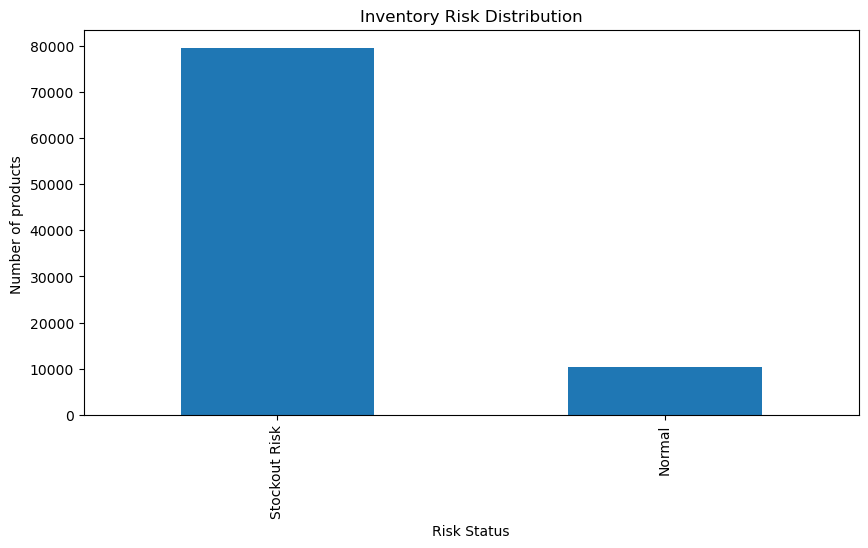

In [75]:
# graph

import matplotlib.pyplot as plt
risk_count.plot(kind="bar", figsize=(10,5))

plt.title("Inventory Risk Distribution" )
plt.xlabel("Risk Status")
plt.ylabel("Number of products ")
plt.show()



In [76]:
#Inventory Heath Score

total_product=len(df)
normal_product = (df["Risk_Status"] == "Normal").sum()

health_score= round((normal_product/ total_product)* 100 ,2)

print("inventory health_score:",health_score ,"%")




inventory health_score: 11.62 %


In [77]:
#dataset exporting to power Bi
df.to_csv(r'C:\Users\Admin\FORESIGHT_5_Year_90000_Rows.csv', index=False)

print('Final file saved successfully!')

Final file saved successfully!


In [78]:
import os
print(os.getcwd())

C:\Users\Admin


In [79]:
df.shape

(90000, 26)

In [80]:
df.size


2340000

In [81]:
df.columns

Index(['date', 'sku_id', 'category', 'subcategory', 'product_name',
       'units_sold', 'revenue', 'unit_price', 'unit_cost', 'list_price',
       'promo_flag', 'week', 'season', 'is_holiday', 'promo_event',
       'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point',
       'Year', 'Month', 'weekend', 'Profit', 'Risk_Status', 'Profit_Margin',
       'Reorder_Needed'],
      dtype='object')

# deployment

In [82]:
df.head()

,date,sku_id,category,subcategory,product_name,units_sold,revenue,unit_price,unit_cost,list_price,...,on_order_units,lead_time_days,reorder_point,Year,Month,weekend,Profit,Risk_Status,Profit_Margin,Reorder_Needed
0,2020-08-01,SKU005,3,Cookware,Cookware 1,12,6736.43,561.37,455.74,759.04,...,1,5,70,2020,8,1,1267.55,Stockout Risk,18.816346,1
1,2020-08-01,SKU013,3,Vase,Vase 2,7,8283.70,1183.39,309.39,576.27,...,1,14,60,2020,8,1,6117.97,Stockout Risk,73.855523,1
2,2020-08-01,SKU011,3,Fan,Fan 3,11,7763.83,705.80,200.36,301.74,...,5,11,54,2020,8,1,5559.87,Stockout Risk,71.612464,1
3,2020-05-01,SKU012,3,Lamp,Lamp 4,21,8108.10,386.10,156.99,299.95,...,26,12,77,2020,5,0,4811.31,Stockout Risk,59.339549,1
4,2020-08-01,SKU018,2,Iron,Iron 5,5,5692.54,1138.51,223.77,372.73,...,12,5,59,2020,8,1,4573.69,Normal,80.345329,0


In [83]:
import flask
print(flask.__version__)

3.1.2


C:\Users\Admin\AppData\Local\Temp\ipykernel_13996\3294412508.py:2: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print(flask.__version__)


In [84]:
#creatng flas folder
import os

os.makedirs('foresight_flask/templates', exist_ok=True)

print('Folders created')

Folders created


In [85]:
app_code = '''
from flask import Flask, render_template, request
import pandas as pd
import pickle

app = Flask(__name__)

# Load model
with open('rf_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load feature names
with open('feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

@app.route('/')
def home():
    return render_template('index.html', features=feature_names)

@app.route('/predict', methods=['POST'])
def predict():

    values = []

    for feature in feature_names:
        values.append(float(request.form[feature]))

    input_df = pd.DataFrame([values], columns=feature_names)

    prediction = model.predict(input_df)[0]

    return render_template(
        'index.html',
        features=feature_names,
        prediction=round(prediction, 2)
    )

if __name__ == '__main__':
    app.run(host='127.0.0.1', port=5001, debug=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print('app.py created')

app.py created


In [86]:
#HTML CODE RUN ARO

html_code = '''
<!DOCTYPE html>
<html>
<head>
    <title>FORESIGHT Revenue Prediction</title>
    <style>
        body{
            font-family:Arial;
            background:#eef5f7;
            margin:40px;
        }
        h1{text-align:center;}

        form{
            width:400px;
            margin:auto;
            background:white;
            padding:25px;
            border-radius:10px;
            box-shadow:0 2px 10px rgba(0,0,0,0.1);
        }

        label{font-weight:bold;}

        input{
            width:100%;
            padding:8px;
            margin:8px 0 16px;
        }

        button{
            width:100%;
            padding:10px;
            background:#2563eb;
            color:white;
            border:none;
            border-radius:5px;
            font-size:16px;
        }

        .result{
            text-align:center;
            margin-top:20px;
            font-size:22px;
            color:#111827;
        }
    </style>
</head>
<body>

<h1>FORESIGHT Revenue Prediction</h1>

<form action='/predict' method='post'>

    {% for feature in features %}
        <label>{{ feature }}</label>
        <input type='number' step='any' name='{{ feature }}' required>
    {% endfor %}

    <button type='submit'>Predict Revenue</button>
</form>

{% if prediction %}
<div class='result'>
    Predicted Revenue: <b>{{ prediction }}</b>
</div>
{% endif %}

</body>
</html>
'''

with open('foresight_flask/templates/index.html', 'w') as f:
    f.write(html_code)

print('index.html created')

index.html created


In [87]:

import shutil

shutil.copy('rf_model.pkl', 'foresight_flask/rf_model.pkl')
shutil.copy('feature_names.pkl', 'foresight_flask/feature_names.pkl')


print('Pickle files copied')

Pickle files copied


In [88]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Admin
['.anaconda', '.conda', '.continuum', '.copilot', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '.vscode-shared', '3D Objects', 'aaaa.txt', 'anaconda3', 'app.py', 'AppData', 'Application Data', 'BlinkIT Grocery Data.xlsx', 'calendar.csv', 'Contacts', 'Cookies', 'datasets', 'Dealing_and_Handling_different_types_of_data.ipynb', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'feature_names.pkl', 'FORESIGHT AND INVENTORY PROJECT', 'FORESIGHT.ipynb', 'FORESIGHT_5_Year_90000_Rows.csv', 'foresight_dataset.csv', 'foresight_final_dashboard.csv', 'foresight_flask', 'Foresight_project.csv', 'inventory_snapshots.csv', 'Links', 'Local Settings', 'Microsoft', 'model_features.pkl', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-0

In [89]:
#requiremnet.txt 
req = '''
flask
pandas
scikit-learn
gunicorn
'''

with open('requirements.txt', 'w') as f:
    f.write(req)

print('requirements.txt created')

requirements.txt created


In [90]:
import flask
print('Flask version:', flask.__version__)

Flask version: 3.1.2


C:\Users\Admin\AppData\Local\Temp\ipykernel_13996\1564562076.py:2: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print('Flask version:', flask.__version__)
